# Z24 PDT: 1DCNN-LSTM-ResNet Training

**Author:** LE XUAN THANG

This notebook trains a 17-class condition classifier from the CSV files produced by `PDT_cleaning.ipynb`. The model architecture and training settings follow the teacher's `DCNN-LSTM-ResNet.py`; only the data input differs.


## Experiment design

- Input: an 80-second window sampled at 100 Hz, giving 8,000 time samples.
- Channels: the five sensors shared by every PDT setup: R1V, R2L, R2T, R2V, and R3V.
- Output: one of 17 condition labels (0--16), corresponding to condition folders 1--17.
- Split: six recordings per condition for training, one for validation, and two for testing.
- Isolation: all CSV segments from one source MAT recording stay in the same split.
- Normalization: mean and standard deviation are calculated from training data only.

AVT and FVT are trained separately. Change `MEASUREMENT` below to run the other measurement type.

In [14]:
from pathlib import Path
from datetime import datetime
import json
import os
import sys

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

start = Path.cwd().resolve()
ROOT = next(
    (path for path in (start, *start.parents)
     if (path / "src" / "data" / "pdt_training_data.py").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the shm project or its notebooks folder")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

from src.models.dcnn_lstm_resnet import build_model
from src.data.pdt_training_data import (
    common_channels,
    count_complete_windows,
    latest_complete_run,
    load_windows,
    normalize_from_train,
    read_manifest,
    split_by_recording,
)

print("Project root:", ROOT)
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


Project root: C:\Users\phuotran\Data\research\shm
TensorFlow: 2.21.0
GPU devices: []


## Configuration

The default AVT run is a complete experiment. A training run can take a long time on CPU. Following the teacher's source, early stopping monitors validation accuracy with a patience of 30 epochs.

In [15]:
MEASUREMENT = "avt"       # Change to "fvt" for a separate FVT experiment
WINDOW_SAMPLES = 8000       # 80 seconds at 100 Hz
BATCH_SIZE = 64
EPOCHS = 100
SEED = 42

tf.keras.utils.set_random_seed(SEED)

RUN_DIR = latest_complete_run(ROOT, MEASUREMENT)
MANIFEST = read_manifest(RUN_DIR)
CHANNELS = list(common_channels(MANIFEST))
NUM_CLASSES = len({int(row["label"]) for row in MANIFEST})

print("Clean-data run:", RUN_DIR)
print("Manifest rows:", len(MANIFEST))
print("Common channels:", CHANNELS)
print("Classes:", NUM_CLASSES)

assert NUM_CLASSES == 17, "Expected all 17 PDT conditions"
assert CHANNELS == ["R1V", "R2L", "R2T", "R2V", "R3V"], (
    "The common sensor layout differs from the verified PDT layout", CHANNELS
)


Clean-data run: C:\Users\phuotran\Data\research\shm\processed\avt\avt_13-09-2026_21-52-09
Manifest rows: 1683
Common channels: ['R1V', 'R2L', 'R2T', 'R2V', 'R3V']
Classes: 17


## Recording-level split

The split is stratified by condition. It uses the source MAT recording as the group, so neighboring segments from a recording cannot leak into another split.

In [16]:
SPLITS = split_by_recording(MANIFEST, seed=SEED)

split_summary = []
for split_name, rows in SPLITS.items():
    split_summary.append({
        "split": split_name,
        "recordings": len({row["source"] for row in rows}),
        "csv_segments": len(rows),
        "complete_windows": count_complete_windows(rows, WINDOW_SAMPLES),
        "conditions": len({int(row["label"]) for row in rows}),
    })

split_summary = pd.DataFrame(split_summary).set_index("split")
display(split_summary)

source_sets = {
    name: {row["source"] for row in rows}
    for name, rows in SPLITS.items()
}
assert source_sets["train"].isdisjoint(source_sets["validation"])
assert source_sets["train"].isdisjoint(source_sets["test"])
assert source_sets["validation"].isdisjoint(source_sets["test"])
print("Recording isolation: OK")

,recordings,csv_segments,complete_windows,conditions
split,,,,
train,102,1122,816,17
validation,17,187,136,17
test,34,374,272,17


Recording isolation: OK


## Load fixed-length windows

CSV segments belonging to the same source recording are ordered and joined first. Each complete 8,000-sample block becomes one 80-second window; a final remainder shorter than 8,000 samples is discarded without crossing into another recording. Loading and normalization use `(examples, time samples, channels)` before the arrays are transposed to the teacher source layout.

In [17]:
x_train, y_train = load_windows(RUN_DIR, SPLITS["train"], CHANNELS, WINDOW_SAMPLES)
x_validation, y_validation = load_windows(
    RUN_DIR, SPLITS["validation"], CHANNELS, WINDOW_SAMPLES
)
x_test, y_test = load_windows(RUN_DIR, SPLITS["test"], CHANNELS, WINDOW_SAMPLES)

for name, x, y in (
    ("train", x_train, y_train),
    ("validation", x_validation, y_validation),
    ("test", x_test, y_test),
):
    print(f"{name:10s} x={x.shape}, y={y.shape}, memory={x.nbytes / 1024**2:.1f} MB")
    assert x.shape[1:] == (WINDOW_SAMPLES, len(CHANNELS))
    assert np.isfinite(x).all()
    assert set(np.unique(y)) == set(range(NUM_CLASSES))

train      x=(816, 8000, 5), y=(816,), memory=124.5 MB
validation x=(136, 8000, 5), y=(136,), memory=20.8 MB
test       x=(272, 8000, 5), y=(272,), memory=41.5 MB


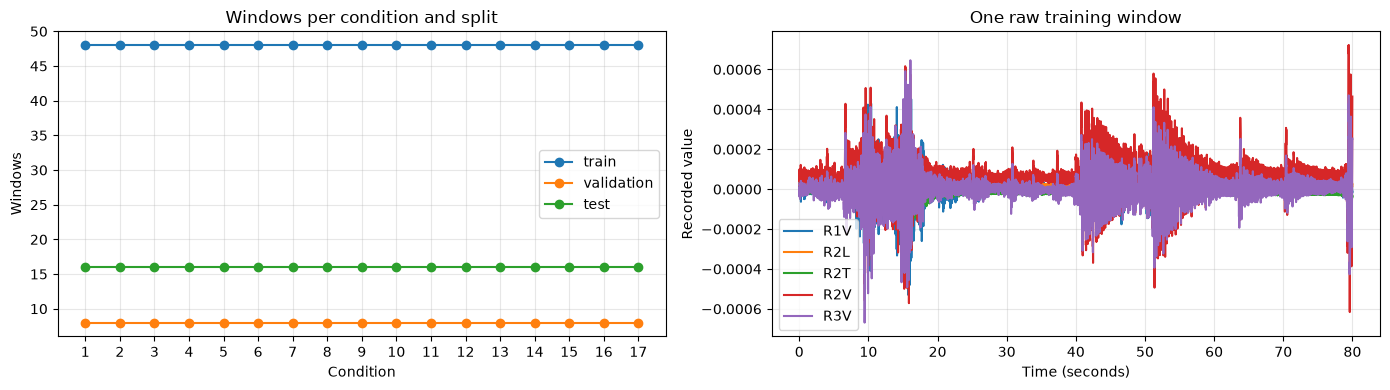

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for split_name, labels in (
    ("train", y_train),
    ("validation", y_validation),
    ("test", y_test),
):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    axes[0].plot(np.arange(1, NUM_CLASSES + 1), counts, marker="o", label=split_name)
axes[0].set_title("Windows per condition and split")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Windows")
axes[0].set_xticks(range(1, NUM_CLASSES + 1))
axes[0].grid(alpha=0.3)
axes[0].legend()

time_seconds = np.arange(WINDOW_SAMPLES) / 100.0
for channel_index, channel_name in enumerate(CHANNELS):
    axes[1].plot(time_seconds, x_train[0, :, channel_index], label=channel_name)
axes[1].set_title("One raw training window")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Recorded value")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## Normalize and prepare backend-neutral arrays

The validation and test arrays use the training mean and standard deviation. Their own statistics are never used to fit preprocessing.

In [19]:
x_train, x_validation, x_test, channel_mean, channel_std = normalize_from_train(
    x_train, x_validation, x_test
)

normalization = pd.DataFrame({
    "channel": CHANNELS,
    "training_mean": channel_mean,
    "training_std": channel_std,
})
display(normalization)

# Match the teacher source: (examples, 5 channels, 8,000 time samples).
x_train = np.ascontiguousarray(x_train.transpose(0, 2, 1))
x_validation = np.ascontiguousarray(x_validation.transpose(0, 2, 1))
x_test = np.ascontiguousarray(x_test.transpose(0, 2, 1))
print("Teacher input shapes:", x_train.shape, x_validation.shape, x_test.shape)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
validation_ds = (
    tf.data.Dataset.from_tensor_slices((x_validation, y_validation))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


,channel,training_mean,training_std
0,R1V,0.000016,0.000070
1,R2L,0.000034,0.000045
2,R2T,-0.000048,0.000072
3,R2V,0.000007,0.000181
4,R3V,-0.000063,0.000238


Teacher input shapes: (816, 5, 8000) (136, 5, 8000) (272, 5, 8000)


## Build the model

Following the teacher source exactly, each normalized window is transposed from `(8000, 5)` to `(5, 8000)` before it enters the model.

In [20]:
tf.keras.backend.clear_session()
model = build_model(
    input_shape=(len(CHANNELS), WINDOW_SAMPLES),
    num_classes=NUM_CLASSES,
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 8000)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3, 64)     │  3,584,064 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3, 64)     │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3, 64)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3, 64)     │      4,160 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 3, 64)     │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3, 64)     │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 3, 64)     │          0 │ conv1d_2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3, 256)    │     16,640 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3, 256)    │     16,640 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3, 256)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 3, 256)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 3, 64)     │     16,448 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 3, 64)     │          0 │ conv1d_5[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 3, 64)     │     12,352 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 3, 64)     │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 3, 256)    │     16,640 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 3, 256)    │     65,792 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 3, 256)    │          0 │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 3, 256)    │          0 │ add_1[0][0]     

 Total params: 5,101,137 (19.46 MB)

 Trainable params: 5,100,497 (19.46 MB)

 Non-trainable params: 640 (2.50 KB)

In [21]:
timestamp = datetime.now().strftime("%d-%m-%Y_%H-%M-%S")
ARTIFACT_DIR = ROOT / "artifacts" / "dcnn_lstm_resnet" / f"{MEASUREMENT}_{timestamp}"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=False)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=30, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ARTIFACT_DIR / "model_1DCNN_LSTM_ResNet.h5",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
]
print("Artifacts:", ARTIFACT_DIR)


Artifacts: C:\Users\phuotran\Data\research\shm\artifacts\dcnn_lstm_resnet\avt_20-09-2026_15-11-57


## Train

Validation accuracy guides early stopping and model checkpointing, following the teacher's source. Test data is not passed to `fit()`.

In [22]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/100


c:\Users\phuotran\Data\research\shm\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0674 - loss: 3.0793

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.0674 - loss: 3.0793 - val_accuracy: 0.0441 - val_loss: 4.0654
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1532 - loss: 2.7081

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1532 - loss: 2.7081 - val_accuracy: 0.0588 - val_loss: 3.9225
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1728 - loss: 2.5799

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1728 - loss: 2.5799 - val_accuracy: 0.1176 - val_loss: 3.1002
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2157 - loss: 2.4515 - val_accuracy: 0.0147 - val_loss: 3.0811
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2623 - loss: 2.3989 - val_accuracy: 0.0515 - val_loss: 3.0873
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3125 - loss: 2.2589 - val_accuracy: 0.0809 - val_loss: 2.9281
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3591 - loss: 2.0998 - val_accuracy: 0.0809 - val_loss: 2.8480
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4387 - loss: 1.9014 - val_accuracy: 0.1103 - val_loss: 2.7389
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5539 - loss: 1.6042 - val_accuracy: 0.0662 - val_loss: 2.7062
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5600 - loss: 1.5325 - val_accuracy: 0.1029 - val_

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9105 - loss: 0.3941 - val_accuracy: 0.1324 - val_loss: 3.2312
Epoch 19/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9326 - loss: 0.3161 - val_accuracy: 0.1250 - val_loss: 3.3343
Epoch 20/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9375 - loss: 0.2589

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9375 - loss: 0.2589 - val_accuracy: 0.1618 - val_loss: 3.4398
Epoch 21/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9436 - loss: 0.2730 - val_accuracy: 0.0735 - val_loss: 3.4002
Epoch 22/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9044 - loss: 0.3456 - val_accuracy: 0.1029 - val_loss: 3.4520
Epoch 23/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9265 - loss: 0.3058 - val_accuracy: 0.0662 - val_loss: 3.9404
Epoch 24/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9608 - loss: 0.1995 - val_accuracy: 0.0662 - val_loss: 4.2593
Epoch 25/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9657 - loss: 0.1819 - val_accuracy: 0.0956 - val_loss: 3.6390
Epoch 26/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9681 - loss: 0.2027 - val_accuracy: 0.0662 - val_loss: 5.3274
Epoch 27/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9681 - loss: 0.1478 - val_accuracy: 0.0662 

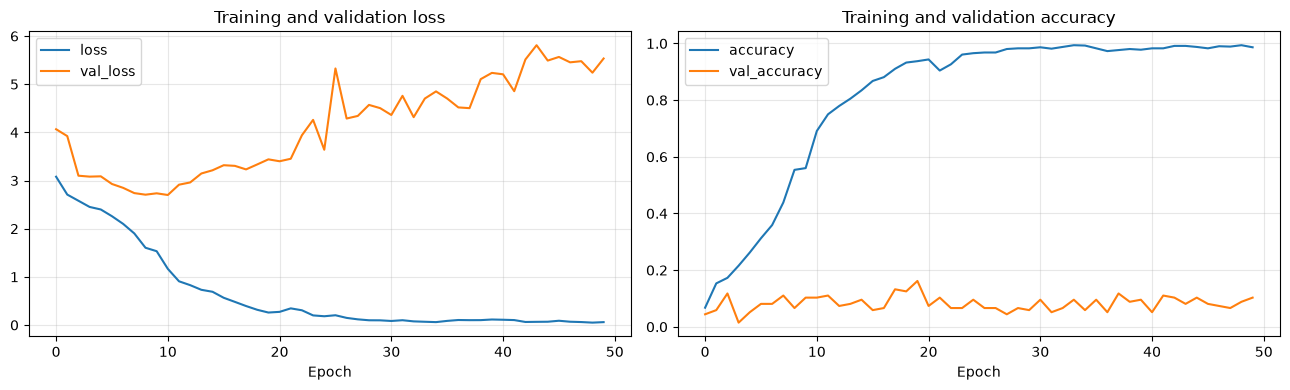

In [23]:
history_frame = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
history_frame[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
history_frame[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Training and validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final test evaluation

Run this cell after training has finished. The test split provides the final unbiased estimate for this experiment.

Test loss: 3.5937
Test accuracy: 0.1581


,precision,recall,f1-score,support
01: undamaged_reference_1,0.000,0.000,0.000,16.000
02: pier_settlement_system_installation,0.091,0.062,0.074,16.000
03: pier_settlement_20mm,0.500,0.375,0.429,16.000
04: pier_settlement_40mm,0.031,0.062,0.042,16.000
05: pier_settlement_80mm,0.143,0.125,0.133,16.000
06: pier_settlement_95mm,0.000,0.000,0.000,16.000
07: foundation_tilt,0.139,0.312,0.192,16.000
08: undamaged_reference_3,0.000,0.000,0.000,16.000
09: concrete_spalling_12m2,0.077,0.062,0.069,16.000
10: concrete_spalling_24m2,0.000,0.000,0.000,16.000


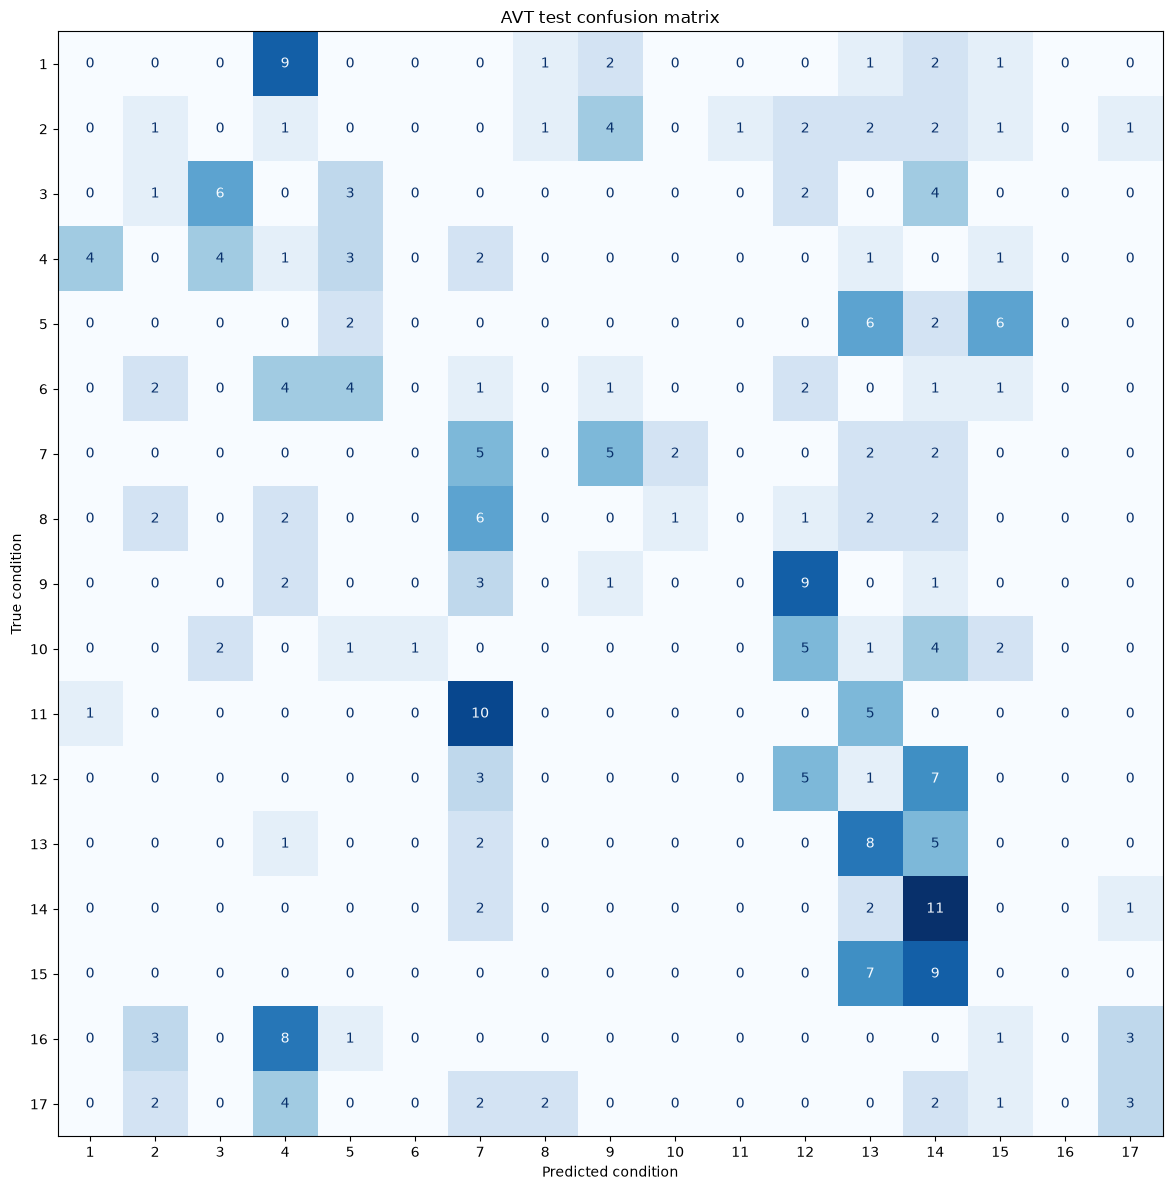

In [24]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
probabilities = model.predict(test_ds, verbose=0)
predictions = probabilities.argmax(axis=1)

condition_names = [
    next(row["condition_name"] for row in MANIFEST if int(row["label"]) == label)
    for label in range(NUM_CLASSES)
]
report = classification_report(
    y_test,
    predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=[f"{index + 1:02d}: {name}" for index, name in enumerate(condition_names)],
    output_dict=True,
    zero_division=0,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
display(pd.DataFrame(report).T.round(3))

matrix = confusion_matrix(y_test, predictions, labels=np.arange(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=np.arange(1, NUM_CLASSES + 1),
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{MEASUREMENT.upper()} test confusion matrix")
ax.set_xlabel("Predicted condition")
ax.set_ylabel("True condition")
plt.tight_layout()
plt.show()

## Save reproducible outputs

The saved model must be used together with the same channel order, window length, and normalization values.

In [25]:
model.save(ARTIFACT_DIR / "final_model.keras")
history_frame.to_csv(ARTIFACT_DIR / "history.csv", index_label="epoch")
pd.DataFrame(report).T.to_csv(ARTIFACT_DIR / "classification_report.csv")
np.savetxt(ARTIFACT_DIR / "confusion_matrix.csv", matrix, fmt="%d", delimiter=",")

experiment = {
    "measurement": MEASUREMENT,
    "clean_data_run": str(RUN_DIR.relative_to(ROOT)),
    "window_samples": WINDOW_SAMPLES,
    "model_input_layout": "channels x time_samples",
    "sampling_rate_hz": 100,
    "channels": CHANNELS,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": EPOCHS,
    "completed_epochs": len(history.history["loss"]),
    "seed": SEED,
    "recordings_per_split": {
        name: len({row["source"] for row in rows})
        for name, rows in SPLITS.items()
    },
    "normalization_mean": channel_mean.tolist(),
    "normalization_std": channel_std.tolist(),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
}
(ARTIFACT_DIR / "experiment.json").write_text(
    json.dumps(experiment, indent=2), encoding="utf-8"
)
print("Saved model and evaluation files to:", ARTIFACT_DIR)

Saved model and evaluation files to: C:\Users\phuotran\Data\research\shm\artifacts\dcnn_lstm_resnet\avt_20-09-2026_15-11-57


In [26]:
# Final accuracy summary
train_loss, train_accuracy = model.evaluate(train_ds, verbose=0)
validation_loss, validation_accuracy = model.evaluate(validation_ds, verbose=0)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Training accuracy:   {train_accuracy:.2%}")
print(f"Validation accuracy: {validation_accuracy:.2%}")
print(f"Test accuracy:       {test_accuracy:.2%}")

Training accuracy:   96.45%
Validation accuracy: 16.18%
Test accuracy:       15.81%
